In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [6]:
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])
df.head()


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
df.info()
df['label'].value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


label
ham     4825
spam     747
Name: count, dtype: int64

In [8]:
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})


In [9]:
X = df['message']  # features
y = df['label_num']  # target labels


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [11]:
vectorizer = CountVectorizer()
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)


In [12]:
model = MultinomialNB()
model.fit(X_train_vectorized, y_train)


MultinomialNB()

In [13]:
y_pred = model.predict(X_test_vectorized)


In [14]:
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.9919282511210762


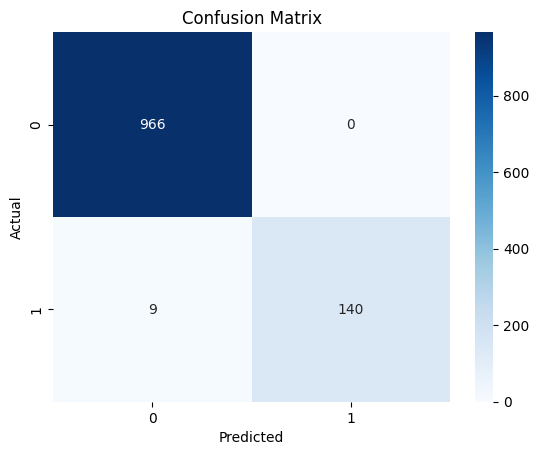

In [15]:
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [16]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.99      1.00      1.00       966
           1       1.00      0.94      0.97       149

    accuracy                           0.99      1115
   macro avg       1.00      0.97      0.98      1115
weighted avg       0.99      0.99      0.99      1115



In [17]:
sample = ["Congratulations! You have won a free iPhone!", 
          "Hi, are we meeting for lunch today?"]
sample_vectorized = vectorizer.transform(sample)
prediction = model.predict(sample_vectorized)

for msg, pred in zip(sample, prediction):
    print(f"Message: {msg} => {'Spam' if pred == 1 else 'Ham'}")


Message: Congratulations! You have won a free iPhone! => Spam
Message: Hi, are we meeting for lunch today? => Ham


In [18]:
import joblib
joblib.dump(model, 'spam_detector_model.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')


['vectorizer.pkl']